Umbralizacion binaria y binaria inversa

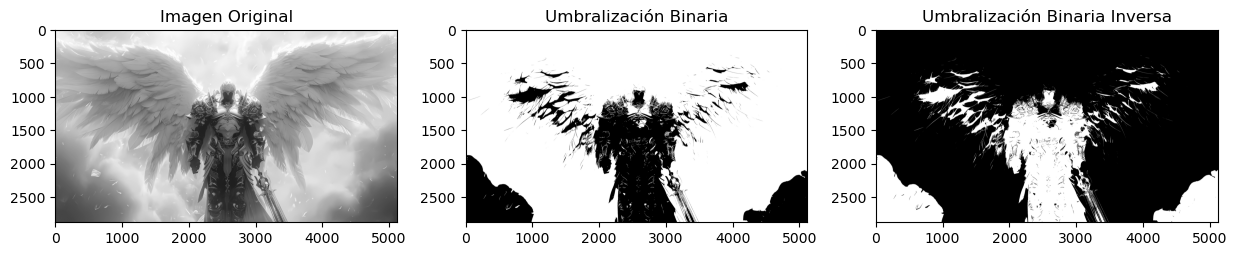

In [13]:
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread('Fond.jpg',0)

# umbralización binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)

# umbralización binaria inversa
_, umbral_binario_in = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(15, 8))
plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap='gray') 
plt.title('Imagen Original')


plt.subplot(1, 3, 2)
plt.imshow(umbral_binario, cmap='gray') 
plt.title('Umbralización Binaria')


plt.subplot(1, 3, 3)
plt.imshow(umbral_binario_in, cmap='gray') 
plt.title('Umbralización Binaria Inversa')

plt.show()


UMBRALIZACION GLOBAL UMBRALIZACION ISODATA 

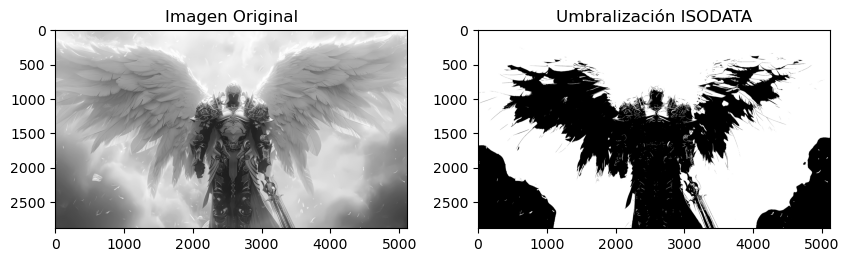

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata(image):
    # Decidimos umbral inicial de 0 a 255
    umbral=128 #Se puede cambiar el valor cuando se requiera
    while True:
        grupo1 = image[image <= umbral] #grupo donde el umbral es mayor o igual al valor determinado
        grupo2 = image[image > umbral] #mayor al determinado

        # Calculamos las medias de ambos grupos
        media1 = np.mean(grupo1) 
        media2 = np.mean(grupo2) 

        #calculamos el nuevo valor del umbral
        nuevo_umbral = (media1 + media2) / 2
        # Si el nuevo umbral es igual al inicial se detine

        if abs(nuevo_umbral - umbral) < 0.5:
            break
        umbral = nuevo_umbral
    return umbral


imagen = cv2.imread('Fond.jpg', 0)
umbral_isodata = isodata(imagen)
_, umbralizacion_iso=cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,7))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(umbralizacion_iso, cmap='gray')
plt.title('Umbralización ISODATA')

plt.show()  

UMBRALIZACION DE 2 PICOS

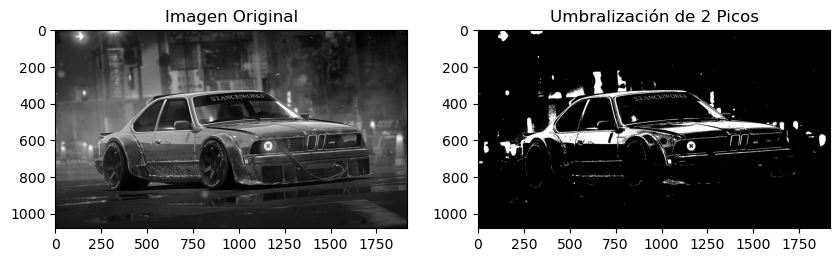

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    # Calculo de histograma
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]) #Hago uso del histograma

    #seleccionamos los dos picos
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico) #diferencias entre los picos
    primer_pico=np.argmax(pico_dif[:128]) #pico hasta 127
    segundo_pico=np.argmax(pico_dif[128:])+128 #pico de 120 para adelante

    #calculo del umbral
    umbral=int((primer_pico + segundo_pico) / 2)
    return umbral

# Cargar la imagen en escala de grises
imagen = cv2.imread('BMW_635.jpg', 0)
umbral_2_picos = dos_picos(imagen)
_, nueva=cv2.threshold(imagen,umbral_2_picos,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10,7))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(nueva, cmap='gray') 
plt.title('Umbralización de 2 Picos')

plt.show()

UMBRALIZACION CON OTSU

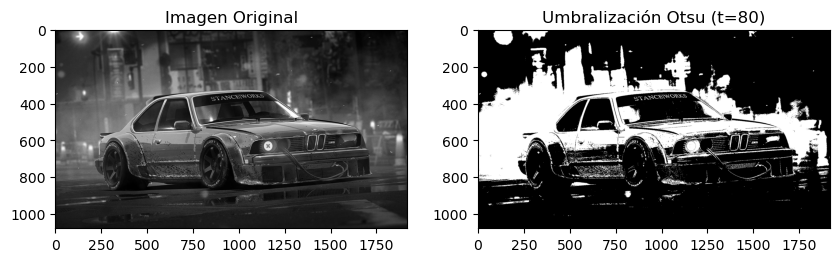

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def otsu_threshold(image):
    # Calcular histograma (256 niveles) y probabilidades de ocurrencia
    hist, _ = np.histogram(image.ravel(), bins=256, range=(0, 256))
    total = image.size
    prob = hist / total

    # Cálculos acumulados (clase de fondo hasta t)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))

    # Mu total de la imagen
    mu_total = mu[-1]

    # Evitar divisiones por cero
    sigma_b_squared = (mu_total * omega - mu) ** 2 / (omega * (1 - omega) + 1e-8)

    # Umbral que maximiza la varianza entre clases
    otsu_t = np.argmax(sigma_b_squared)
    return otsu_t


image = cv2.imread('BMW_635.jpg', 0)  # escala de grises
otsu_t = otsu_threshold(image)
imagen_fin = np.where(image > otsu_t, 255, 0).astype(np.uint8)  # aplicamos el umbral a la imagen

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title(f'Umbralización Otsu (t={otsu_t})')

plt.show()

UMBRALIZACION VARIABLE PARTICION DE UNA IMAGEN

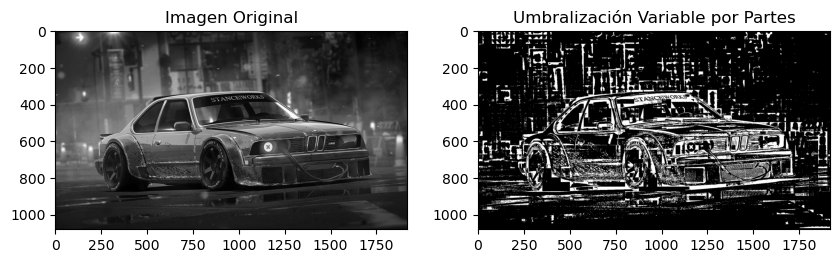

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def varibale_part(image,tam_bloque,c):
    umbral_img=np.zeros_like(image) #creamos una imagen vacia del mismo tamaño que la original
    for y in range(0,image.shape[0],tam_bloque): #recorremos filas
        for x in range(0,image.shape[1],tam_bloque): #recorremos columnas
            bloque=image[y:y+tam_bloque,x:x+tam_bloque] #obtenemos el bloque
            bloq_media=np.mean(bloque) #intensidad media del bloque
            umbral=bloq_media-c #calculamos el umbral restando la constante c a la media 
            umbral_img[y:y+tam_bloque,x:x+tam_bloque]=(bloque>umbral)+255 # umb binaria
    return umbral_img

tam_b=25
c=10

imagen = cv2.imread('BMW_635.jpg', 0)
img_fin = varibale_part(imagen, tam_b, c)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1,2,2)
plt.imshow(img_fin, cmap='gray')
plt.title('Umbralización Variable por Partes')
plt.show()



PROPIEDADES LOCALES

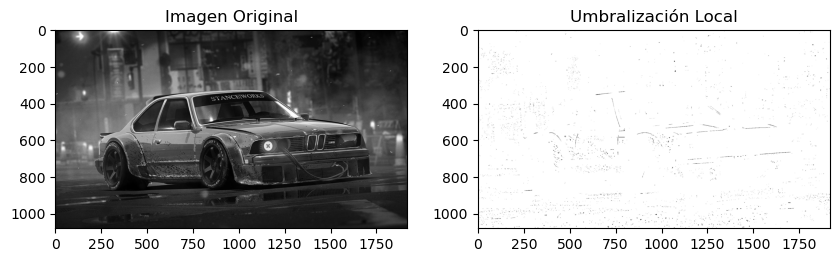

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('BMW_635.jpg', 0) #cargamos la imagen en escala de grises

def local(image,tamanio_ventana,k):
    umbr_img=np.zeros_like(image) #creamos una imagen vacia del mismo tamaño que la original
    #Definir un rastreo de imagen con padding para evitar problemas en los bordes
    pad=tamanio_ventana//2
    padded_image=cv2.copyMakeBorder(image,pad,pad,pad,pad,cv2.BORDER_REPLICATE)

    # recorremos cada pixel
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana=padded_image[y:y+tamanio_ventana,x:x+tamanio_ventana] #obtenemos la ventana

            #Calculo de emedia y desviacion 
            mean_local=np.mean(ventana) #intensidad media de la ventana
            std_mean=np.std(ventana) #desviacion estandar de la ventana
            #Calculo del umbral 
            umbral=mean_local-(k*std_mean) #calculamos el umbral usando la formula de Niblack
            umbr_img[y,x]= 155 if image[y,x] > umbral else 0 #umb binaria
    return umbr_img

tam_ventana=25
k=2

img_fin= local(image,tam_ventana,k)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1,2,2)
plt.imshow(img_fin, cmap='gray')
plt.title('Umbralización Local')
plt.show()



           

VARIABLE CON OPEN CV

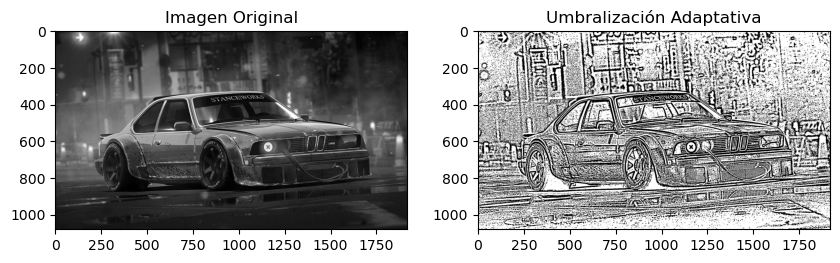

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('BMW_635.jpg', 0) #cargamos la imagen en escala de grises


ventana=15
k=2
imagen_fin=cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,k)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1,2,2)
plt.imshow(imagen_fin, cmap='gray')
plt.title('Umbralización Adaptativa')
plt.show()




Practica Otsu con Formulas

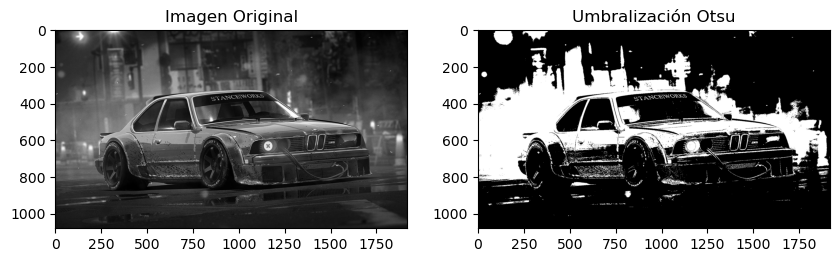

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_threshold(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    hist = hist / hist.sum()
    best_t = 0
    max_var = 0
    for t in range(1, 256):
        w1 = hist[:t].sum()
        w2 = 1 - w1
        if w1 > 0 and w2 > 0:
            mean1 = (np.arange(t) * hist[:t]).sum() / w1
            mean2 = (np.arange(t, 256) * hist[t:]).sum() / w2
            var = w1 * w2 * (mean1 - mean2)**2
            if var > max_var:
                max_var = var
                best_t = t
    return best_t

image = cv2.imread('BMW_635.jpg', 0)
otsu_t = otsu_threshold(image)
_, imagen_fin = cv2.threshold(image, otsu_t, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title('Umbralización Otsu')

plt.show()

Practica 4 Uso del Metodo

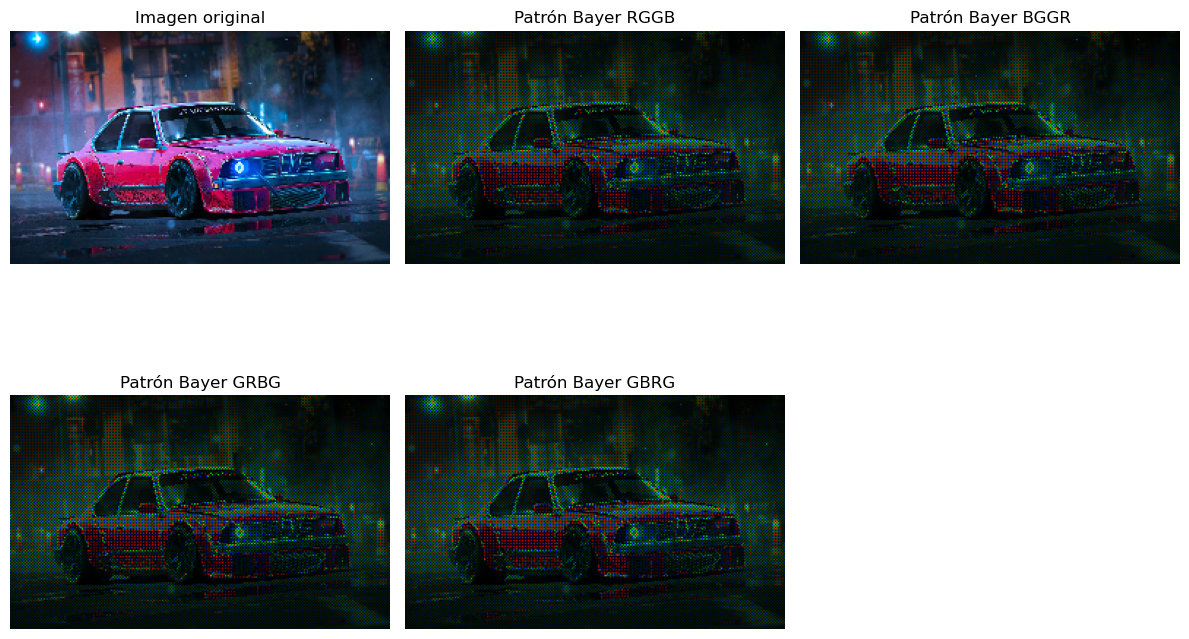

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen
img = cv2.imread("BMW_635.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


img = cv2.resize(img,(260,160))

h,w,_ = img.shape

def aplicar_bayer(img,patron):

    resultado = np.zeros_like(img)

    if patron=="RGGB":

        resultado[0::2,0::2,0] = img[0::2,0::2,0]  
        resultado[0::2,1::2,1] = img[0::2,1::2,1]  
        resultado[1::2,0::2,1] = img[1::2,0::2,1]  
        resultado[1::2,1::2,2] = img[1::2,1::2,2]  

    if patron=="BGGR":

        resultado[0::2,0::2,2] = img[0::2,0::2,2]  
        resultado[0::2,1::2,1] = img[0::2,1::2,1]  
        resultado[1::2,0::2,1] = img[1::2,0::2,1]  
        resultado[1::2,1::2,0] = img[1::2,1::2,0]  

    if patron=="GRBG":

        resultado[0::2,0::2,1] = img[0::2,0::2,1]  
        resultado[0::2,1::2,0] = img[0::2,1::2,0]  
        resultado[1::2,0::2,2] = img[1::2,0::2,2]  
        resultado[1::2,1::2,1] = img[1::2,1::2,1]  

    if patron=="GBRG":

        resultado[0::2,0::2,1] = img[0::2,0::2,1]  
        resultado[0::2,1::2,2] = img[0::2,1::2,2]  
        resultado[1::2,0::2,0] = img[1::2,0::2,0]  
        resultado[1::2,1::2,1] = img[1::2,1::2,1]  

    return resultado


patrones = ["RGGB","BGGR","GRBG","GBRG"]

plt.figure(figsize=(12,8))


plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")

for i,p in enumerate(patrones):

    img_bayer = aplicar_bayer(img,p)

    
    img_bayer = cv2.resize(img_bayer,None,fx=3,fy=3,interpolation=cv2.INTER_NEAREST)

    plt.subplot(2,3,i+2)
    plt.imshow(img_bayer)
    plt.title("Patrón Bayer "+p)
    plt.axis("off")

plt.tight_layout()
plt.show()

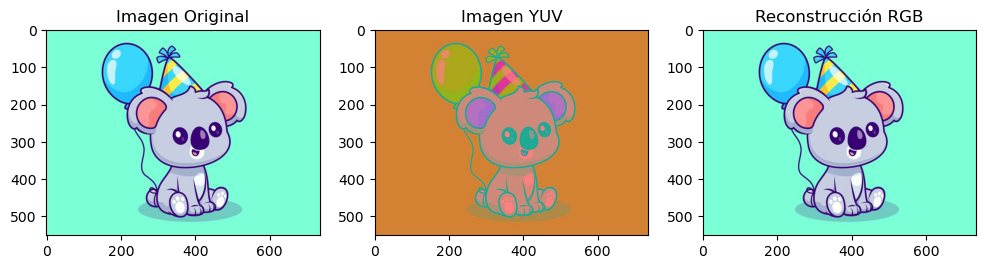

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Leer imagen original
img = cv2.imread("imgKoala.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convertir a YUV
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# Convertir nuevamente a RGB
img_rgb_recon = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Imagen Original")

plt.subplot(1,3,2)
plt.imshow(img_yuv)
plt.title("Imagen YUV")

plt.subplot(1,3,3)
plt.imshow(img_rgb_recon)
plt.title("Reconstrucción RGB")

plt.show()